In [2]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('balls.jpg') # load image
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY) # convert to gray

blur = cv2.GaussianBlur(gray,(15,15),0) # apply blurring

_,otsu = cv2.threshold(blur,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (20,60))
closed = cv2.morphologyEx(otsu, cv2.MORPH_CROSS, kernel)
opened = cv2.morphologyEx(closed, cv2.MORPH_OPEN, kernel)

contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
filtered = [cnt for cnt in contours if cv2.contourArea(cnt) > 500]  # adjust this value

# #Draw contours on original image
img_copy = img.copy()



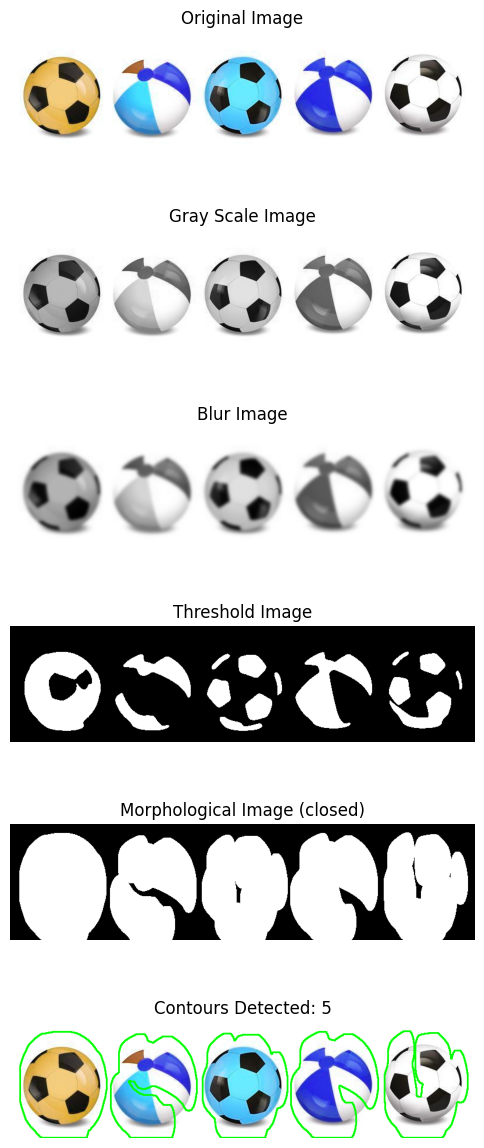

<Figure size 640x480 with 0 Axes>

In [3]:
plt.figure(figsize=(6, 15))  # Width x Height in inches

plt.subplot(6, 1, 1)
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')

plt.subplot(6, 1, 2)
plt.imshow(gray, cmap='gray')
plt.title("Gray Scale Image")
plt.axis('off')

plt.subplot(6, 1, 3)
plt.imshow(blur, cmap='gray')
plt.title("Blur Image")
plt.axis('off')

plt.subplot(6, 1, 4)
plt.imshow(otsu, cmap='gray')
plt.title("Threshold Image")
plt.axis('off')

plt.subplot(6, 1, 5)
plt.imshow(closed, cmap='gray')
plt.title("Morphological Image (closed)")
plt.axis('off')


plt.subplot(6, 1, 6)
plt.imshow(cv2.drawContours(img_copy, filtered, -1, (0, 255, 0), 2))
plt.title(f"Contours Detected: {len(filtered)}")
plt.axis('off')
plt.show()

plt.tight_layout()
plt.show()

Saved: object_1.jpg
Saved: object_2.jpg
Saved: object_3.jpg
Saved: object_4.jpg
Saved: object_5.jpg


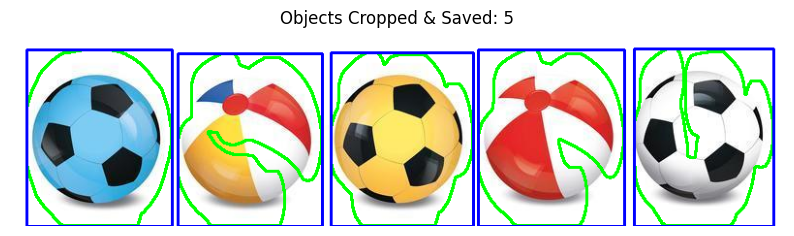

In [4]:
# Loop through each filtered contour to crop and save the object
for i, cnt in enumerate(filtered):
    # Get bounding box around the contour
    # Returns: x, y = top-left corner, w, h = width and height
    x, y, w, h = cv2.boundingRect(cnt)

    # Draw a rectangle on the original image for visual reference
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (255, 0, 0), 2)  # Blue box

    # Crop the object from the original image using NumPy slicing
    cropped_object = img[y:y+h, x:x+w]

    # Save the cropped object to file (you can change path if needed)
    filename = f"object_{i+1}.jpg"  # Output name: object_1.jpg, object_2.jpg, ...
    cv2.imwrite(filename, cropped_object)

    # (Optional) Print confirmation
    print(f"Saved: {filename}")

    
# Show final result with bounding boxes drawn
plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.title(f"Objects Cropped & Saved: {len(filtered)}")
plt.axis('off')
plt.show()

In [6]:
#Organized Dataset
#Module 9: Organized Dataset for AI 
import os

output_dir = "dataset/ball"
os.makedirs(output_dir, exist_ok=True)

for i, cnt in enumerate(filtered):
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img[y:y+h, x:x+w]
    filename = os.path.join(output_dir, f"ball_{i+1}.jpg")
    cv2.imwrite(filename, cropped)

In [7]:
#Labeling dataset for Machine Learnin
#Metadata file: ball_labels.csv containing image + box + label info

import os
import cv2
import pandas as pd

output_dir = "dataset/ball"
os.makedirs(output_dir, exist_ok=True)

# Simulate label data collection
label_data = []

for i, cnt in enumerate(filtered):
    x, y, w, h = cv2.boundingRect(cnt)
    cropped = img[y:y+h, x:x+w]
    filename = f"ball_{i+1}.jpg"
    filepath = os.path.join(output_dir, filename)
    cv2.imwrite(filepath, cropped)

    # Add label info
    label_data.append({
        "filename": filename,
        "x": x,
        "y": y,
        "w": w,
        "h": h,
        "label": "ball"
    })

# Save to CSV
df = pd.DataFrame(label_data)
df.to_csv("ball_labels.csv", index=False)
print("Saved ball_labels.csv")


Saved ball_labels.csv


In [2]:
#Module 11 YOLO Dataset Format Preparation

import os
import pandas as pd
import cv2

# Load metadata
df = pd.read_csv("ball_labels.csv")

# Map label to class ID (e.g., "ball" = 0)
label_to_id = {"ball": 0}

# Folder where images are stored
image_dir = "dataset/ball"
labels_dir = "dataset/ball"
os.makedirs(labels_dir, exist_ok=True)

# Loop through metadata rows
for _, row in df.iterrows():
    filename = row['filename']
    label = row['label']
    class_id = label_to_id[label]

    # Load image to get width and height
    image_path = os.path.join(image_dir, filename)
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # Convert bbox to YOLO format
    x_center = (row['x'] + row['w'] / 2) / w
    y_center = (row['y'] + row['h'] / 2) / h
    width = row['w'] / w
    height = row['h'] / h

    # Write to TXT file (one per image)
    txt_filename = os.path.splitext(filename)[0] + ".txt"
    txt_path = os.path.join(labels_dir, txt_filename)
    with open(txt_path, 'w') as f:
        f.write(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
